In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
class Value:
    
    # We are going to want to keep the information about how each Value was created in an expression / computation graph
    # I think the reason for this is this will be the information that backpropagation uses to compute gradients
    # backpropogration is the recursive application of the chain rule backwards through the computation graph\
    # I've learned how to do gradient descent in CS 357 but I believe we just let numpy compute the gradient for us.
    # So backprop is simply calculating the gradient, which is needed in grad descent. 
    # I also believe that it "analytically" computes the gradient with the expression graph rather than numerically approximating it

    def __init__(self, data, _children=(), _op='', label=''): # I don't know what self is (maybe a pointer to the object itself? data is the number I pass)
        self.data = data
        self.grad = 0.0 # gradiant dL/d(self.data)
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other): # a + b is internally called by python as a.__add__(b)
        out = Value(self.data + other.data, (self, other), '+') # self.data is a python FP number so this + is default python addition
        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        return out
    
    def tanh(self):
        n = self.data
        t = (math.exp(2*n) - 1) / (math.exp(2*n) + 1)
        out = Value(t, (self,), 'tanh')
        return out
    
a = Value(3.0, label='a')
b = Value(4.0, label='b')
c = a + b; c.label = 'c'
d = a * c; d.label = 'd'
L = d + c; L.label = 'L' # L "loss function"

In [3]:
# Want to visualize expression graphs
# So this graph visualizes the output of the "forward pass"

from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in the graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child) # recursive step
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={ 'rankdir': 'LR' }) # LR means left to right
    
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record) node for it
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)
            # and connect this node to it
            dot.edge(uid+ n._op, uid)
    
    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
        
    return dot

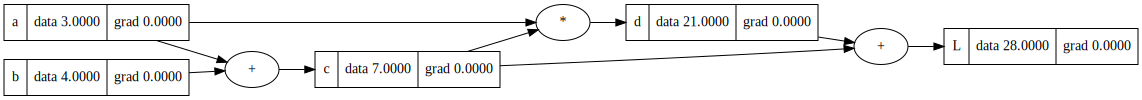

In [4]:
draw_dot(L)

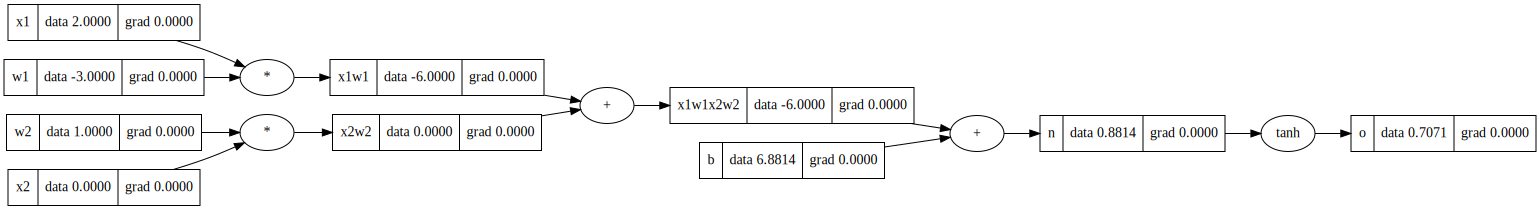

In [5]:
# This is a single neuron

# inputs (data)
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1 * w1; x1w1.label = 'x1w1'
x2w2 = x2 * w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1x2w2'
n = x1w1x2w2 + b; n.label = 'n'

# n is the cell body raw activation, without the activation function applied yet
# We will use tanh as the activation function. Sigmoid function is another common activation function. Just want a "squashing function"?

o = n.tanh(); o.label = 'o' # output of neuron after activation function
draw_dot(o)

# Remember that my activation function is different than my loss function

# I believe we are most interested in do/dw1 and do/dw2?

In [ ]:
# Okay I think the backpropagation algorithm is going to look something like:
# Resursively step through the nodes, starting from the output node (activation or loss function?)
# def partial_grad(nodes): for this node:
    # look at node._op (to get the node.grad of the children nodes of this node) - note that exactly 1 operation created each node
    # compute the gradient (partial derivative) of this node wrt the children nodes from a list of hard-coded derivatives for each operation
    # Multiply to apply the chain rule (which way down the graph am I moving?)
    
    # for all children:
    # So this is: d(this node) / d(child node) = this.get_partial_grad(child) * partial_grad(child) <- recursive step